### Predict the salary of the employees based on the years of experience using Simple Linear Regression:----


##### Step 1: Import all the necessary libraries:

In [356]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   sklearn.model_selection import train_test_split
from   sklearn.preprocessing   import StandardScaler
from   sklearn.linear_model    import LinearRegression
from   sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

##### Step 2: Load the Dataset

In [357]:
df = pd.read_csv('Salary_Data.csv')

In [358]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


#### OBSERVATIONS:

1.  The above dataset has two columns

    (a.) YearsExperience ---------->   Years of experience

    (b.) Salary          ---------->   Salary based on the years of expericence.

##### Step 3: Perform the Data Exploration:

In [359]:
print("Total length of the dataset is:", len(df))

Total length of the dataset is: 30


In [360]:
print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (30, 2)


In [361]:
print(df.columns)

Index(['YearsExperience', 'Salary'], dtype='object')


In [362]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


In [363]:
print(df.describe())

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


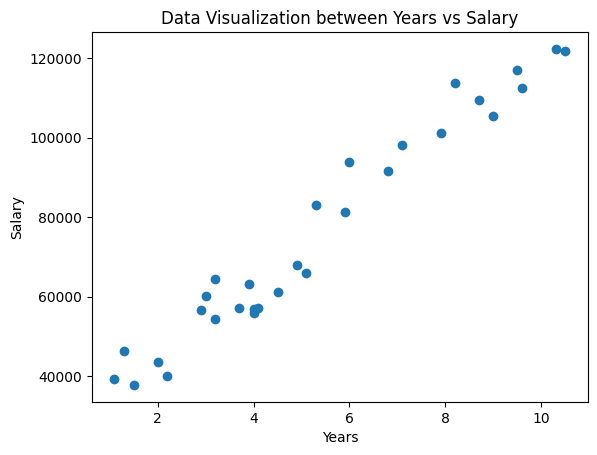

In [364]:
plt.scatter(df['YearsExperience'], df['Salary'])
plt.title("Data Visualization between Years vs Salary")
plt.xlabel('Years')
plt.ylabel('Salary')
plt.show()

#### OBSERVATIONS:

1.  With the increase in the years of experience, the salary of the employee also increases.

#### Step 4: Perform Data Cleaning and Validation

In [365]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [366]:
df[df.duplicated()]

,YearsExperience,Salary


#### OBSERVATIONS:

1.  There are no duplicate records in the dataset.

#### Step 5: Divide the dataset into independent and dependent variables

In [367]:
X = df[['YearsExperience']]

Y = df['Salary']

In [368]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [369]:
print(Y)

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64


#### OBSERVATIONS:

1.  The dataset is divided into independent and dependent variables.

#### Step 6: Divide the independent and dependent variables into training and testing data:

In [370]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [371]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [372]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [373]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (24, 1)
Shape of the input testing  data is: (6, 1)


In [374]:
Y_train

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [375]:
Y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [376]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (24,)
Shape of the output testing  data is: (6,)


#### Step 7: Train the linear regression model

In [377]:
from sklearn.linear_model import LinearRegression

#### Create the object for linear regression

lin = LinearRegression()

#### using the object for Linear Regression, train the model

lin.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### OBSERVATIONS:

1.  The linear regression model has been trained with the help of the training data.

##### Step 8: Predict the Model

In [378]:
Y_pred = lin.predict(X_test)

In [379]:
Y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

#### Step 9: Compare the Actual vs Predicted Results and store the results in a dataframe

In [380]:
res = pd.DataFrame({
    'Actual Results '      :        Y_test           ,
    'Predicted Results'    :        Y_pred           ,
    'Residual'             :        (Y_test - Y_pred)                
})

In [381]:
res

,Actual Results,Predicted Results,Residual
27,112635.0,115790.210113,-3155.210113
15,67938.0,71498.278095,-3560.278095
23,113812.0,102596.868661,11215.131339
17,83088.0,75267.804224,7820.195776
8,64445.0,55477.792045,8967.207955
9,57189.0,60189.699707,-3000.699707


##### Step 10:  Compute the Model Parameters

In [382]:
print("Slope of the model is:", lin.coef_[0])
print("Intercept of the model is:", lin.intercept_)

Slope of the model is: 9423.815323030976
Intercept of the model is: 25321.583011776813


#### Step 11: Perform the Regression metrics

In [383]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

mae = mean_absolute_error(Y_test, Y_pred)

print("Mean Absolute error of the model is:", mae)

Mean Absolute error of the model is: 6286.453830757749


In [384]:
mse = mean_squared_error(Y_test, Y_pred)

print("Mean Squared error of the model is:", mse)

Mean Squared error of the model is: 49830096.85590839


In [385]:
rmse = root_mean_squared_error(Y_test, Y_pred)

print("Root Mean Squared error of the model is:", rmse)

Root Mean Squared error of the model is: 7059.04362190151


In [386]:
r2 = r2_score(Y_test, Y_pred)

print("R2 Score  of the model is:", r2)

R2 Score  of the model is: 0.9024461774180497


#### OBSERVATIONS:

1. As the R2 Score of the model is 0.9 which is very high. So the model is working fine.

#### Step 12: Dump the model

In [387]:
import joblib

#### Dump the model

joblib.dump(lin, "salary_model.pkl")

['salary_model.pkl']